# Gland segmentation with CINDER

CINDER segments an image by decoding every pixel coordinate $x$ with an
implicit neural representation (INR) conditioned on the feature maps $z$ of an
image encoder:

$$
y = \mathrm{INR}_{\theta(z)}\big(\phi(x, z)\big).
$$

The condition can enter in two places, and this notebook compares them on the
[GlaS](https://warwick.ac.uk/fac/cross_fac/tia/data/glascontest/) gland
segmentation benchmark:

- **Input modulation.** `FUTONGate` encodes each coordinate with a Fourier
  tensor network (FUTON) and gates the encoding with the encoder maps sampled at
  that coordinate, so the condition varies within the image.
- **Weight modulation.** `WeightDisplacement` predicts, from the final encoder
  map, an additive displacement of the INR's weight matrices for each image, so
  the condition selects a function per image.

We train a FUTON gate over a ReLU MLP, with and without weight modulation, then
compare their training curves, test metrics and predictions, and finish with a
look at how a training step decodes only a fraction of the pixels.

Requirements: `pip install -e ".[train]" matplotlib pandas`, GlaS unpacked in
`GLAS_DIR` (see `cinder/datasets/glas.py` for the layout), and a GPU. The two
short trainings below take about a quarter of an hour on one consumer GPU.

In [1]:
import os
import time
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ignite.engine import Events
from ignite.handlers import create_lr_scheduler_with_warmup
from torch.utils.data import DataLoader
from torchvision.transforms import v2

import cinder as cd
from cinder.datasets import glas

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GLAS_DIR = Path(os.environ.get("GLAS_DIR", "../data/GlaS"))
CROP = (512, 512)  # training crops and inference windows

plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False})
print(f"cinder {cd.__version__} | torch {torch.__version__} | {device}")

cinder 0.1.0 | torch 2.10.0+cu126 | cuda


## Data

GlaS has 85 training images and two test sets, Test A (60) and Test B (20),
which the challenge reports separately. Training uses random $512 \times 512$
crops with flips, small rotations and color jitter, as in
`configs/dataset/default.yaml`. The test sets keep each gland's integer label
(`instance_labels=True`), which the object-level metrics need.

In [2]:
train_transform = v2.Compose(
    [
        v2.RandomCrop(CROP, pad_if_needed=True),
        v2.RandomHorizontalFlip(),
        v2.RandomApply([v2.RandomRotation(15)], p=0.5),
        v2.RandomApply([v2.ColorJitter(0.2, 0.2, 0.2)], p=0.5),
    ]
)
train_set = cd.SegmentationDataset(glas.create_datalist(GLAS_DIR, "train"), transform=train_transform)
test_sets = {
    split: cd.SegmentationDataset(glas.create_datalist(GLAS_DIR, split), instance_labels=True)
    for split in ("testA", "testB")
}
print(f"train: {len(train_set)} images | " + " | ".join(f"{k}: {len(v)} images" for k, v in test_sets.items()))

train: 85 images | testA: 60 images | testB: 20 images


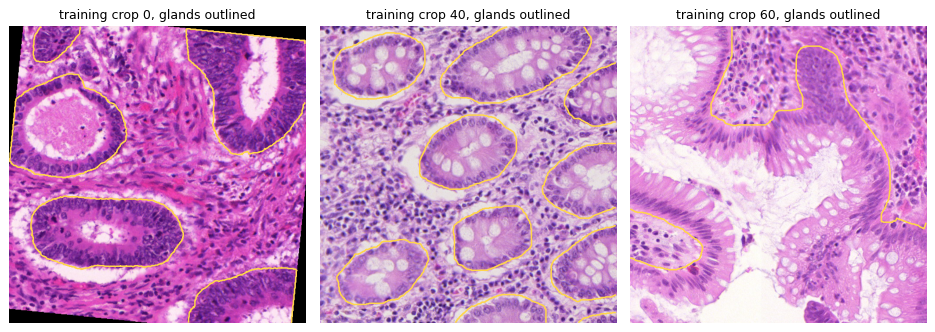

In [3]:
def show_image(ax, image, mask=None, title=None):
    ax.imshow(image.permute(1, 2, 0).numpy())
    if mask is not None:
        ax.contour(mask.squeeze(0).numpy() > 0, levels=[0.5], colors="#ffd54a", linewidths=1.2)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
for ax, index in zip(axes, (0, 40, 60)):
    image, mask = train_set[index]
    show_image(ax, image, mask, f"training crop {index}, glands outlined")
plt.tight_layout()

## Models

Both models share the encoder, a DINOv3 ConvNeXt-Tiny from `timm` whose last
four stages condition the decoder, and the INR, a ReLU MLP with one hidden
layer. `CINDER` builds the parts from factories and sizes them to each other:
the modulator receives the INR spec, the coordinate dimension, the output width
and the shapes of the encoder maps.

| Model | Modulator |
|---|---|
| FUTON gate | `FUTONGate`: a sinc basis with 512 components per axis, a CP combiner of rank 256, and the four maps fused by summation |
| FUTON gate + weight modulation | `ListModulators([WeightDisplacement, FUTONGate])`, innermost first: the displacement wraps the INR, and the gate wraps the displacement |

During training each step decodes a random quarter of the pixels
(`sampling_ratio=0.25`); inference always decodes them all.

In [4]:
ENCODER = "convnext_tiny.dinov3_lvd1689m"  # any timm backbone with dense features works
GATE = (
    "futon",
    {
        "basis": ("sinc", {"num_components": list(CROP), "grid_size": list(CROP)}),
        "combiner": ("cp", {"rank": 256}),
        "fusion": "sum",
    },
)
DISPLACEMENT = ("displacement", {"conditioner": "mlp"})


def build_model(weight_modulation: bool) -> cd.CINDER:
    modulator = partial(cd.ListModulators, modulators=[DISPLACEMENT, GATE]) if weight_modulation else GATE
    return cd.CINDER(
        in_channels=3,
        out_channels=1,
        in_size=CROP,
        encoder=partial(cd.TimmEncoder, model_name=ENCODER, pretrained=True, out_indices=(-4, -3, -2, -1)),
        inr=partial(cd.MLP, hidden_layers=1),
        modulator=modulator,
        sampling_ratio=0.25,
    )


models = {"FUTON gate": build_model(False), "FUTON gate + weight modulation": build_model(True)}
for name, model in models.items():
    print(f"{name:32s} {sum(p.numel() for p in model.parameters()) / 1e6:5.1f}M parameters")

FUTON gate                        28.5M parameters
FUTON gate + weight modulation    35.3M parameters


## Training

The recipe follows `configs/trainer/glas.yaml`: AdamW at $10^{-4}$ with weight
decay $0.01$, a cosine schedule with a 1% linear warmup, bfloat16 autocast, and
a Dice + cross-entropy loss. `SampledLoss` gathers the target at the pixels the
model decoded. The full recipe runs 10k iterations; 1k is enough to see the
difference between the models.

In [5]:
MAX_ITERS, BATCH_SIZE = 1000, 8


def train(model: cd.CINDER, max_iters: int = MAX_ITERS) -> np.ndarray:
    model.to(device)
    loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True, pin_memory=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    loss_fn = cd.SampledLoss(cd.DiceCELoss(sigmoid=True, squared_pred=True).to(device), model)
    trainer = cd.create_trainer(model, optimizer, loss_fn, device, amp=True)
    schedule = create_lr_scheduler_with_warmup(
        torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters),
        warmup_start_value=1e-6,
        warmup_duration=max(2, max_iters // 100),
    )
    trainer.add_event_handler(Events.ITERATION_STARTED, schedule)
    losses = []
    trainer.add_event_handler(Events.ITERATION_COMPLETED, lambda engine: losses.append(engine.state.output))

    start = time.perf_counter()
    trainer.run(loader, max_epochs=1, epoch_length=max_iters)  # the loader cycles as needed
    minutes = (time.perf_counter() - start) / 60
    print(f"{max_iters} iterations in {minutes:.1f} min, loss {np.mean(losses[-50:]):.3f} over the last 50")
    return np.asarray(losses)


losses = {name: train(model) for name, model in models.items()}

1000 iterations in 7.2 min, loss 0.104 over the last 50


1000 iterations in 7.6 min, loss 0.084 over the last 50


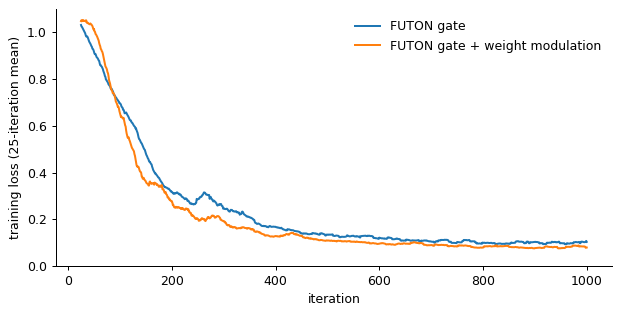

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
window = 25
for name, values in losses.items():
    smoothed = np.convolve(values, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window, len(values) + 1), smoothed, label=name, linewidth=1.6)
ax.set(xlabel="iteration", ylabel=f"training loss ({window}-iteration mean)", ylim=(0, 1.1))
ax.legend(frameon=False)
plt.tight_layout()

## Evaluation

Test images keep their native size and are predicted with a sliding window of
$512 \times 512$ tiles blended under Gaussian weights. Pixel Dice and HD95 score
the gland mask; object F1, object Dice and object Hausdorff score the
individual glands, as the GlaS challenge does, after splitting the prediction
into connected components. Test A and Test B are reported separately.

In [7]:
inferer = cd.SlidingWindowInferer(roi_size=CROP, sw_batch_size=8, overlap=0.25, mode="gaussian", amp=True)


def evaluate(model: cd.CINDER, dataset: cd.SegmentationDataset) -> dict[str, float]:
    metrics = {
        "Dice": cd.DiceMetric(),
        "HD95": cd.HausdorffDistanceMetric(),
        "Object F1": cd.ObjectF1Metric(),
        "Object Dice": cd.ObjectDiceMetric(),
        "Object Hausdorff": cd.ObjectHausdorffMetric(),
    }
    evaluator = cd.create_evaluator(model, metrics, device, inferer=inferer)
    evaluator.run(DataLoader(dataset, batch_size=1, num_workers=4))
    return evaluator.state.metrics


results = pd.DataFrame(
    {(name, split): evaluate(model, dataset) for name, model in models.items() for split, dataset in test_sets.items()}
).T.rename_axis(["model", "split"])
results.round(3)

Dice    HD95  Object F1  Object Dice  \
model                          split                                          
FUTON gate                     testA  0.931  48.679      0.268        0.874   
                               testB  0.885  62.051      0.121        0.702   
FUTON gate + weight modulation testA  0.934  41.400      0.166        0.869   
                               testB  0.885  54.338      0.059        0.711   

                                      Object Hausdorff  
model                          split                    
FUTON gate                     testA            65.655  
                               testB           225.877  
FUTON gate + weight modulation testA            66.731  
                               testB           213.488

Pixel Dice is already high after 1k iterations, and Test B, the harder split,
trails Test A for both models. The object metrics are stricter: object F1
counts every connected component of the prediction, so the speckle that remains
this early in training costs precision, and object Hausdorff is dominated by a
few unmatched glands. The full 10k-iteration recipe cleans both up, and single
runs this short vary from seed to seed, so read the table as a sketch.

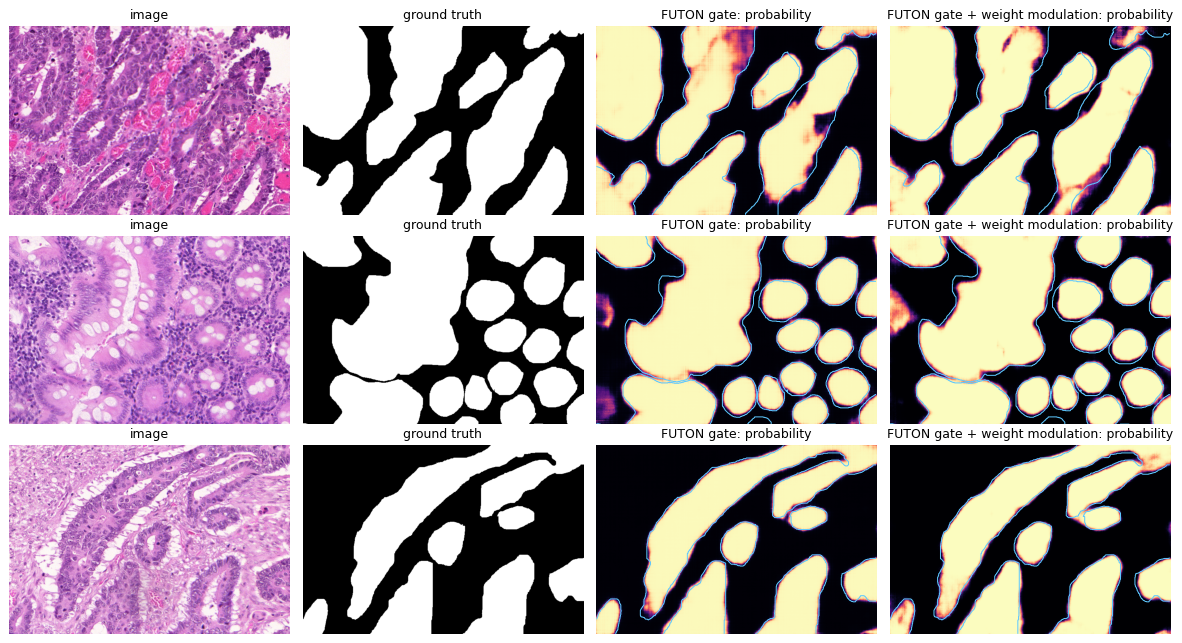

In [8]:
@torch.no_grad()
def predict(model: cd.CINDER, image: torch.Tensor) -> torch.Tensor:
    model.eval()
    return inferer(image[None].to(device), model)[0, 0].sigmoid().cpu()


examples = [test_sets["testA"][i] for i in (3, 17, 41)]
fig, axes = plt.subplots(len(examples), 2 + len(models), figsize=(3.3 * (2 + len(models)), 2.4 * len(examples)))
for row, (image, target) in zip(axes, examples):
    show_image(row[0], image, title="image")
    row[1].imshow(target.squeeze(0) > 0, cmap="gray")
    row[1].set_title("ground truth", fontsize=10)
    row[1].axis("off")
    for ax, (name, model) in zip(row[2:], models.items()):
        ax.imshow(predict(model, image), cmap="magma", vmin=0, vmax=1)
        ax.contour(target.squeeze(0).numpy() > 0, levels=[0.5], colors="#5ec8ff", linewidths=0.8)
        ax.set_title(f"{name}: probability", fontsize=10)
        ax.axis("off")
plt.tight_layout()

## Decoding a fraction of the pixels

CINDER decodes each coordinate independently, so a training step need not
decode the whole crop. With `sampling_ratio=0.25` it draws a random quarter of
the pixel coordinates, shared across the batch, and `SampledLoss` scores the
targets at the same pixels; the encoder still sees the whole image, and
inference decodes every pixel. Below are the coordinates one step decodes,
colored by the predicted probability.

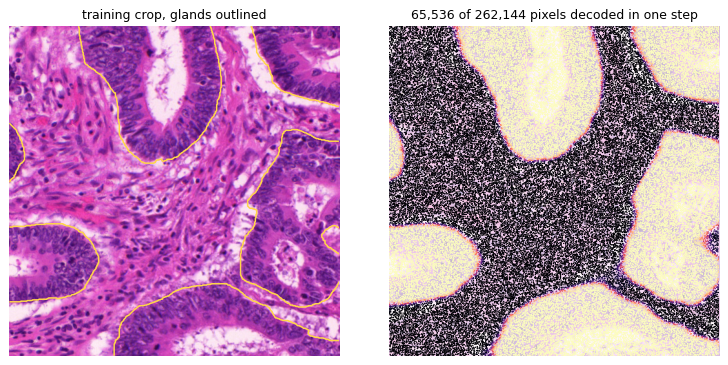

In [9]:
model = models["FUTON gate + weight modulation"].train()  # training mode samples the coordinates
image, mask = train_set[0]
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
    logits = model(image[None].to(device))  # (1, 1, N) for the N sampled pixels
model.eval()
indices = model.sample_indices.cpu()
rows, cols = indices // CROP[1], indices % CROP[1]
probabilities = logits[0, 0].float().sigmoid().cpu()

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.1))
show_image(axes[0], image, mask, "training crop, glands outlined")
axes[1].imshow(image.permute(1, 2, 0).numpy(), alpha=0.3)
axes[1].scatter(cols, rows, c=probabilities, cmap="magma", vmin=0, vmax=1, s=1.2, linewidths=0)
axes[1].set_title(f"{len(indices):,} of {CROP[0] * CROP[1]:,} pixels decoded in one step", fontsize=10)
axes[1].axis("off")
plt.tight_layout()

## Next steps

The full recipes live in `configs/`, and `scripts/train.sh` runs them on one or
several GPUs, for example
`scripts/train.sh --gpus=1 --dataset=glas --model=futongate_weight_relu --path.dataset_dir=/path/to/GlaS`,
with `scripts/eval.sh` scoring a checkpoint on Test A and Test B. The model
configs also cover weight modulation of SIREN and FUTON INRs, and every
component, from the basis to the fusion rule, accepts a registry key, a
`(key, parameters)` pair, a factory or a module.